In [67]:
%pip install pandas seaborn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [68]:
DATA_DIR = "../../data/stocks_1d"

In [69]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
from pathlib import Path

# Scan all CSV files in the folder
csv_files = glob.glob(f"{DATA_DIR}/*.csv")
print(f"CSVs trouvés ({len(csv_files)}):")
for f in csv_files:
    print(f"  - {Path(f).name}")

# Dictionary for storing data
prices = {}
for file in csv_files:
    ticker = Path(file).stem.split('_')[0]
    df = pd.read_csv(file, parse_dates=['Date']).set_index('Date')
    prices[ticker] = df['Adj Close']

# Combined DataFrame (common dates)
df_combined = pd.DataFrame(prices).dropna()
print(f"\nPériode commune ({len(df_combined.columns)} stocks):")
print(f"  {df_combined.index.min()} → {df_combined.index.max()}")
print(f"  {len(df_combined)} jours")

CSVs trouvés (16):
  - NEM_1d_2017-01-01_2026-01-01.csv
  - MSFT_1d_2017-01-01_2026-01-01.csv
  - KO_1d_2017-01-01_2026-01-01.csv
  - GS_1d_2017-01-01_2026-01-01.csv
  - AMZN_1d_2017-01-01_2026-01-01.csv
  - GOOGL_1d_2017-01-01_2026-01-01.csv
  - SAP_1d_2017-01-01_2026-01-01.csv
  - JPM_1d_2017-01-01_2026-01-01.csv
  - NESN.SW_1d_2017-01-01_2026-01-01.csv
  - JNJ_1d_2017-01-01_2026-01-01.csv
  - PFE_1d_2017-01-01_2026-01-01.csv
  - PG_1d_2017-01-01_2026-01-01.csv
  - NVDA_1d_2017-01-01_2026-01-01.csv
  - AXP_1d_2017-01-01_2026-01-01.csv
  - TSLA_1d_2017-01-01_2026-01-01.csv
  - AAPL_1d_2017-01-01_2026-01-01.csv

Période commune (16 stocks):
  2017-01-03 00:00:00 → 2025-12-30 00:00:00
  2200 jours


In [70]:
returns = df_combined.pct_change().dropna()
corr_matrix = returns.corr()

print("Corrélations (rendements journaliers):")
print(corr_matrix.round(4))
print(f"\nCorrélation max: {corr_matrix.values.max():.4f}")
print(f"Corrélation min: {corr_matrix.values.min():.4f}")

Corrélations (rendements journaliers):
            NEM    MSFT      KO      GS    AMZN   GOOGL     SAP     JPM  \
NEM      1.0000  0.1456  0.1884  0.1230  0.1192  0.1477  0.1901  0.0997   
MSFT     0.1456  1.0000  0.3395  0.4769  0.6733  0.7047  0.5646  0.4284   
KO       0.1884  0.3395  1.0000  0.3481  0.1576  0.2765  0.3467  0.4213   
GS       0.1230  0.4769  0.3481  1.0000  0.3842  0.4566  0.4472  0.8188   
AMZN     0.1192  0.6733  0.1576  0.3842  1.0000  0.6401  0.4777  0.3066   
GOOGL    0.1477  0.7047  0.2765  0.4566  0.6401  1.0000  0.4873  0.4038   
SAP      0.1901  0.5646  0.3467  0.4472  0.4777  0.4873  1.0000  0.4108   
JPM      0.0997  0.4284  0.4213  0.8188  0.3066  0.4038  0.4108  1.0000   
NESN.SW  0.0735  0.1394  0.2906  0.1027  0.0583  0.1017  0.1757  0.1035   
JNJ      0.1648  0.3051  0.5032  0.3016  0.1412  0.2452  0.2499  0.3382   
PFE      0.1199  0.2878  0.3873  0.2879  0.1831  0.2426  0.2592  0.3260   
PG       0.1670  0.3496  0.6137  0.2582  0.1781  0.2460  0.30

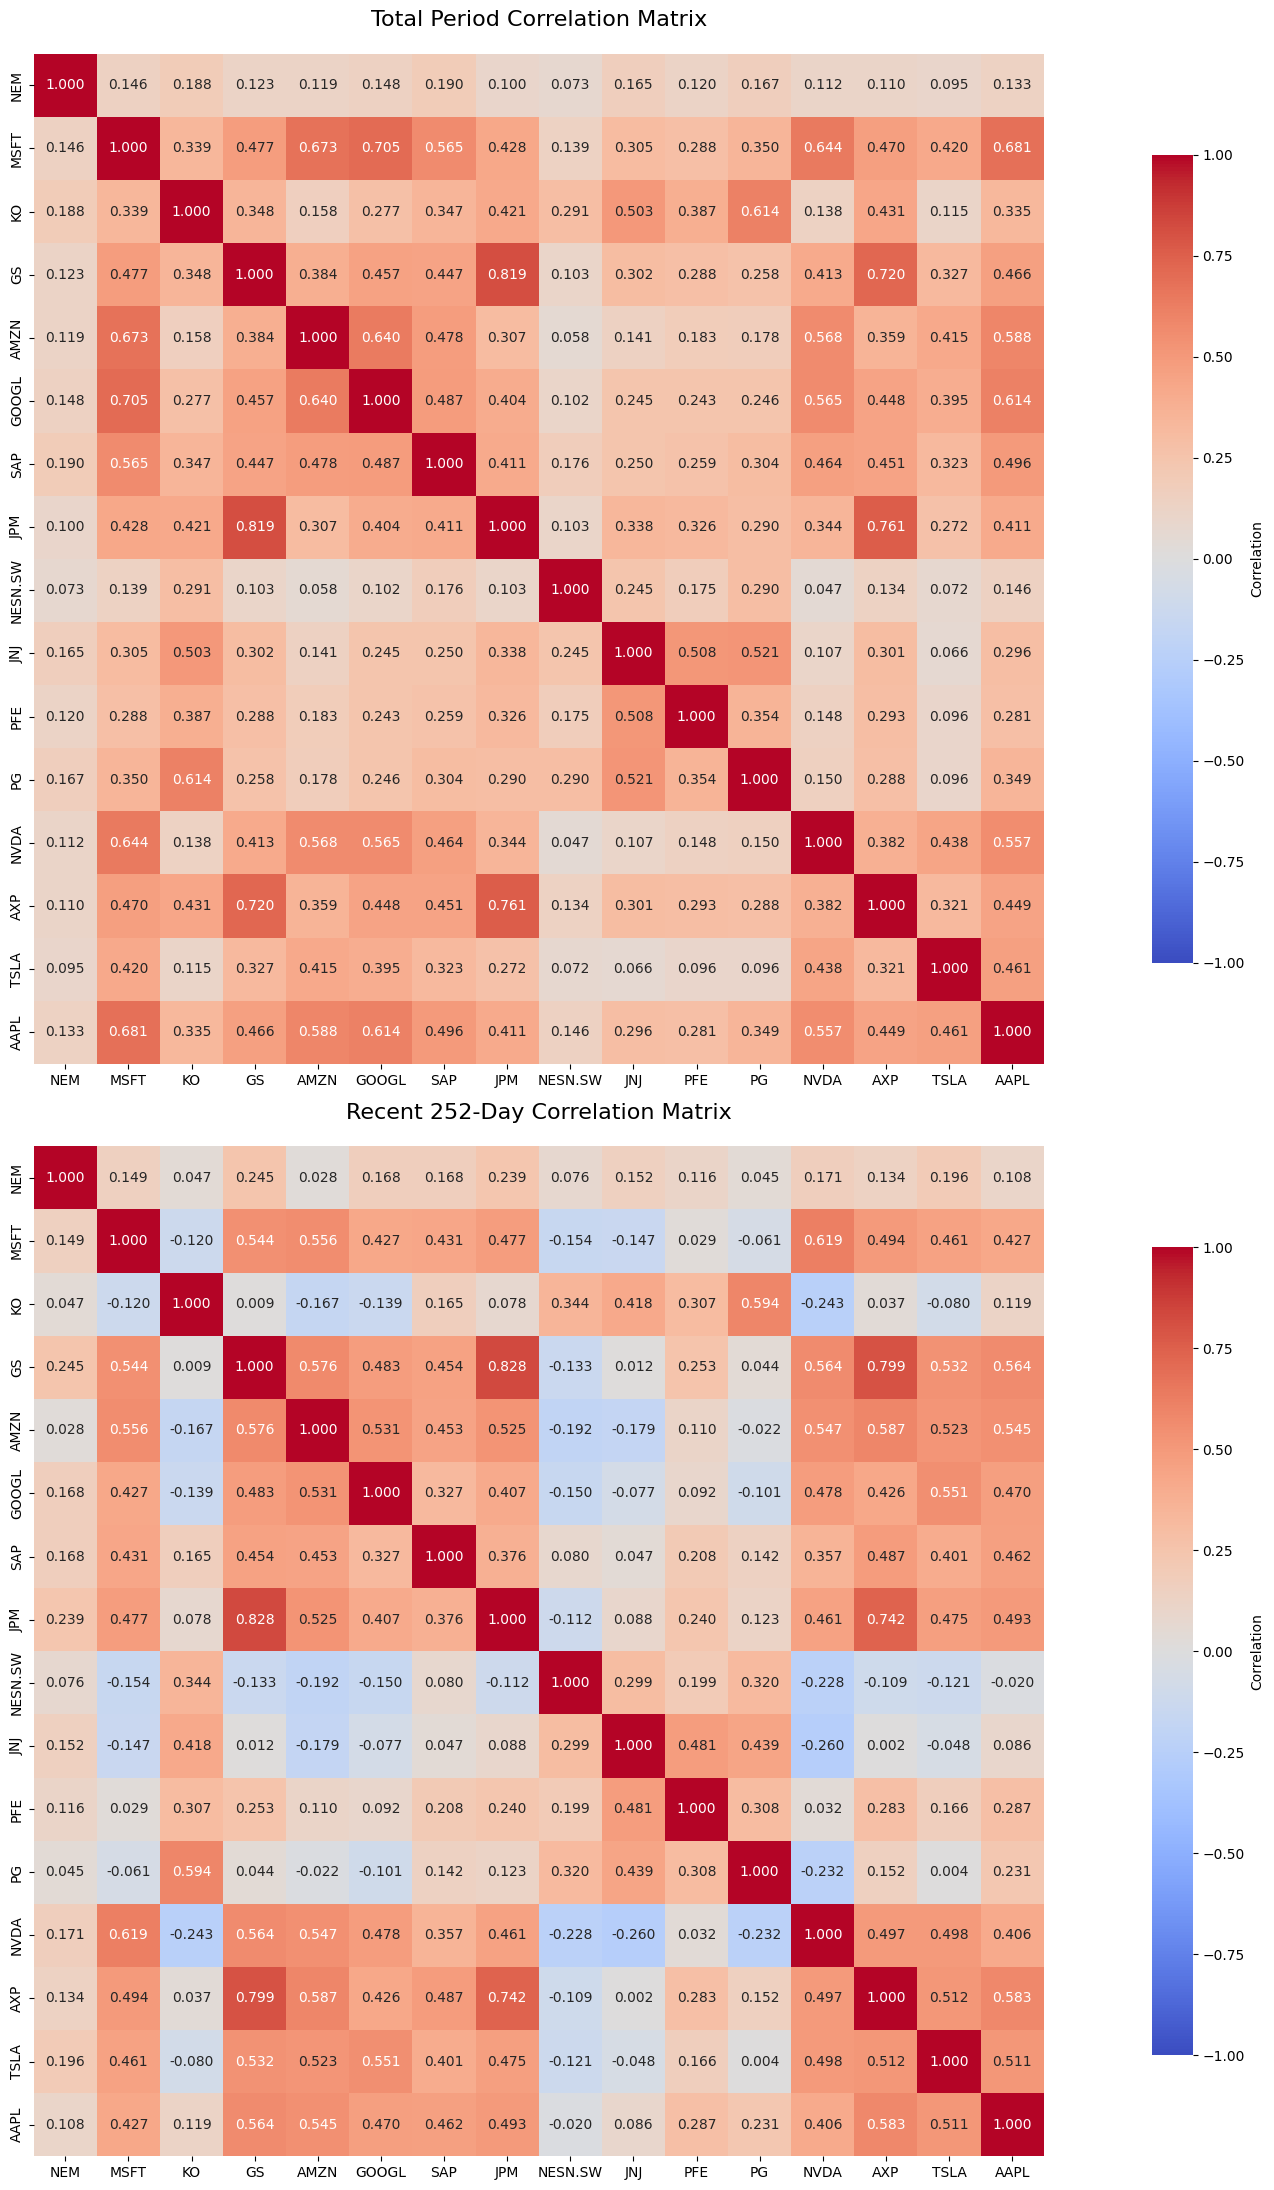

In [71]:
import numpy as np
import pandas as pd

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(22, 22))

# 1. Total Correlation Matrix (BLUE → RED, -1 to +1)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax1)
ax1.set_title('Total Period Correlation Matrix', fontsize=16, pad=20)

# 2. 252-day Correlation Matrix (-1 to +1)
returns = df_combined.pct_change().dropna()
rolling_period = 252
recent_returns = returns.tail(rolling_period)
rolling_corr_matrix = recent_returns.corr()

sns.heatmap(rolling_corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, vmin=-1, vmax=1,
            fmt='.3f', cbar_kws={'shrink': 0.8, 'label': 'Correlation'},
            ax=ax2)
ax2.set_title('Recent 252-Day Correlation Matrix', fontsize=16, pad=20)

plt.tight_layout()
plt.show()